# Results by group complexity (evalmaxsat vs exact)

In [28]:

!pwd

/Users/wilberquito/repos/mspsp/notebooks/smtapi/by-family/maxcdcl-roundingsat


In [29]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent.parent.parent
DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / "instances",
    },
    "figures": FIGURES / pipe,
}

pprint(DIRS)

{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp/data/analysis/smtapi/instances'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp/figures/smtapi')}


In [30]:
instances_description_csv = f"{DIRS['data']['analysis']}/mspsp_stats.csv"
instances_description_df = pd.read_csv(instances_description_csv)
instances_description_df.shape

(1142, 10)

In [31]:
instances_description_df.head(2)

,family,n_activities,n_skills,n_resources,n_precedences,skill_factor,modified_resource_strength,network_complexity,network_density,mspsp_instance
0,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...
1,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...


In [32]:
instances_description_df.columns

Index(['family', 'n_activities', 'n_skills', 'n_resources', 'n_precedences',
       'skill_factor', 'modified_resource_strength', 'network_complexity',
       'network_density', 'mspsp_instance'],
      dtype='object')

In [33]:
# Describe for each family the main stats

save_as = DIRS["data"]["analysis"] / "instances_description_per_family.csv"

by_family_df = instances_description_df.groupby("family")
description_df = by_family_df.describe()
description_df.to_csv(save_as)

# For each each feature describe it per family and save it as a separate csv file

for c in instances_description_df.columns:
    if c in ["instance", "family"]:
        continue
    save_as = DIRS["data"]["analysis"] / f"instances_description_{c}_per_family.csv"
    f_df = by_family_df[c].describe()
    f_df.to_csv(save_as)

In [34]:
# Output for each family the range of modified resource strength values
ranges_mrs_df = by_family_df["modified_resource_strength"].agg(["min", "max"])
ranges_mrs_df

,min,max
family,,
set-1a,0.075758,0.227273
set-1b,0.059055,0.103211
set-2a,0.013515,0.165165
set-2b,0.010753,0.079812
set-2c,0.021164,0.178571
set-3a,0.011719,0.035156
set-3b,0.020833,0.062500


In [35]:
families = instances_description_df["family"].unique()
stats = list()

for f in families:
    f_df = instances_description_df[instances_description_df["family"] == f]
    col = f_df["modified_resource_strength"]
    data = {
        "family": f,
        "min": col.min(),
        "max": col.max(),
        "mean": col.mean(),
        "std": col.std(),
        "q25": col.quantile(0.25),
        "median": col.median(),
        "q75": col.quantile(0.75),
        "iqr": col.quantile(0.75) - col.quantile(0.25),
        "n": col.count(),
    }
    stats.append(data)

stats_df = pd.DataFrame(stats)
stats_df = stats_df.round(4)
stats_df.sort_values("q75")

,family,min,max,mean,std,q25,median,q75,iqr,n
5,set-3a,0.0117,0.0352,0.0209,0.0064,0.0156,0.0198,0.0234,0.0078,216
6,set-3b,0.0208,0.0625,0.0370,0.0114,0.0278,0.0352,0.0417,0.0139,216
3,set-2b,0.0108,0.0798,0.0366,0.0245,0.0160,0.0180,0.0619,0.0458,77
4,set-2c,0.0212,0.1786,0.0561,0.0305,0.0297,0.0488,0.0748,0.0450,91
2,set-2a,0.0135,0.1652,0.0673,0.0331,0.0500,0.0533,0.0847,0.0347,110
1,set-1b,0.0591,0.1032,0.0783,0.0129,0.0625,0.0781,0.0938,0.0312,216
0,set-1a,0.0758,0.2273,0.1548,0.0415,0.1250,0.1625,0.1875,0.0625,216


In [36]:
stats = ["q25", "median", "q75", "iqr", "mean", "std"]
instances_description_df = instances_description_df.merge(
    stats_df[["family"] + stats], on="family", how="inner"
)

stats_columns = {s: f"mrs_{s}" for s in stats}

instances_description_df = instances_description_df.rename(columns=stats_columns)
instances_description_df.head(2)

,family,n_activities,n_skills,n_resources,n_precedences,skill_factor,modified_resource_strength,network_complexity,network_density,mspsp_instance,mrs_q25,mrs_median,mrs_q75,mrs_iqr,mrs_mean,mrs_std
0,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,0.125,0.1625,0.1875,0.0625,0.1548,0.0415
1,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,0.125,0.1625,0.1875,0.0625,0.1548,0.0415


In [37]:
# Read all csv under the wandb directory
wandb_dir = DIRS["data"]["wandb"]

df_wandb = pd.concat(
    [
        pd.read_csv(os.path.join(wandb_dir, f))
        for f in os.listdir(wandb_dir)
        if f.endswith(".csv")
    ],
    ignore_index=True,
)
df_wandb.shape

(27408, 22)

In [38]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like'],
      dtype='object')

In [39]:
# Pick just solvers of interest
exclude_solvers = ["exactpb", "evalmaxsat"]
df_wandb = df_wandb[~df_wandb["solver"].isin(exclude_solvers)]

df_wandb.shape

(13704, 22)

In [40]:
df_wandb["inline_config"].value_counts().sort_index()

inline_config
f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1                1142
f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0                1142
f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=1__pb_like=0    1142
f=opb__s=roundingsat__i=i1=0,i2=0,i3=1,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=0,i2=1,i3=0,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=1,i2=0,i3=0,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=1,i2=1,i3=0,i4=0__pb_like=0    1142
Name: count, dtype: int64

In [41]:
list(stats_columns.values())

['mrs_q25', 'mrs_median', 'mrs_q75', 'mrs_iqr', 'mrs_mean', 'mrs_std']

In [42]:
# Generate bitmask for implied
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied_bitmask"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied_bitmask"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


def add_logarithmic_time(df: pd.DataFrame) -> pd.DataFrame:
    df["solver.log_real_time"] = df["solver.real_time"].apply(lambda x: np.log10(x))
    return df


df_wandb = add_implied_column(df_wandb, check=True)
df_wandb = add_logarithmic_time(df_wandb)

# Merge with hardness dataframe to get the modified resource strength bins
df_wandb = df_wandb.merge(
    instances_description_df[
        ["mspsp_instance", "modified_resource_strength", "family"]
        + list(stats_columns.values())
    ],
    on="mspsp_instance",
)

In [43]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'modified_resource_strength', 'family',
       'mrs_q25', 'mrs_median', 'mrs_q75', 'mrs_iqr', 'mrs_mean', 'mrs_std'],
      dtype='object')

In [44]:
df_wandb["implied_bitmask"].value_counts()

implied_bitmask
0001    2284
0010    2284
0000    2284
1100    2284
1000    2284
0100    2284
Name: count, dtype: int64

In [45]:
df_wandb["solver.real_time"].describe()

count    13704.000000
mean       340.760108
std        284.751696
min          0.030000
25%          2.900000
50%        600.000000
75%        600.000000
max        600.050000
Name: solver.real_time, dtype: float64

In [46]:
df_wandb["solver.log_real_time"].describe()

count    13704.000000
mean         1.730396
std          1.351405
min         -1.522879
25%          0.462398
50%          2.778151
75%          2.778151
max          2.778187
Name: solver.log_real_time, dtype: float64

In [47]:
df_wandb["solver"].value_counts()

solver
maxcdcl        6852
roundingsat    6852
Name: count, dtype: int64

In [48]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'modified_resource_strength', 'family',
       'mrs_q25', 'mrs_median', 'mrs_q75', 'mrs_iqr', 'mrs_mean', 'mrs_std'],
      dtype='object')

In [49]:
mapping_range = (
    df_wandb[["family", "mrs_mean", "mrs_std", "mrs_median", "mrs_iqr"]]
    .drop_duplicates()
    .reset_index()
    .drop(columns="index")
)
mapping_range

,family,mrs_mean,mrs_std,mrs_median,mrs_iqr
0,set-1a,0.1548,0.0415,0.1625,0.0625
1,set-1b,0.0783,0.0129,0.0781,0.0312
2,set-2a,0.0673,0.0331,0.0533,0.0347
3,set-2b,0.0366,0.0245,0.0180,0.0458
4,set-2c,0.0561,0.0305,0.0488,0.0450
5,set-3a,0.0209,0.0064,0.0198,0.0078
6,set-3b,0.0370,0.0114,0.0352,0.0139


In [50]:
# Rename the exact pseudo boolean solver from exactpb to exact

df_wandb["solver"] = df_wandb["solver"].replace({"exactpb": "exact"})
df_wandb["solver"].value_counts()

solver
maxcdcl        6852
roundingsat    6852
Name: count, dtype: int64

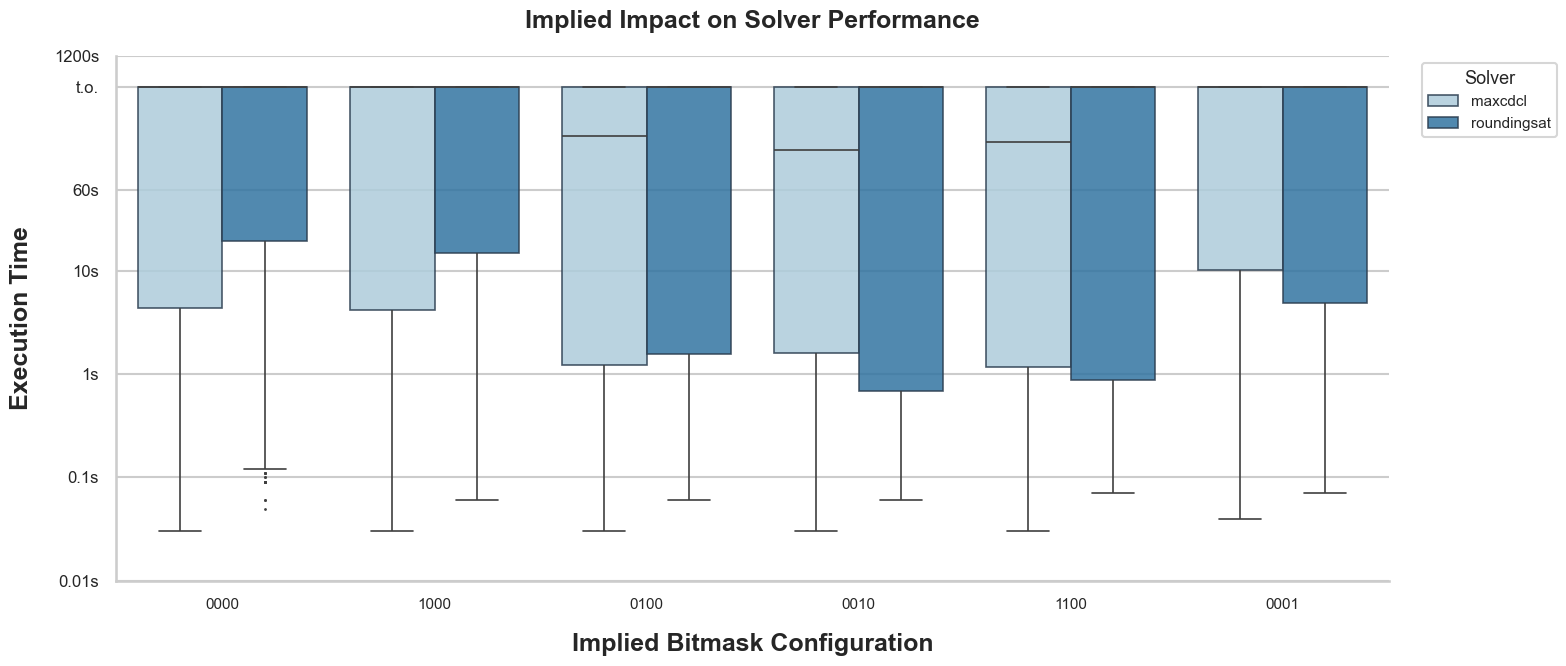

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Setup and Styling ---
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")

# Create a copy for manipulation
by_family_df = df_wandb.copy()
by_family_df["implied_bitmask_str"] = by_family_df["implied_bitmask"].astype(str)

# --- Define Plotting Order ---
implied_order = [
    "0000",
    "1000",
    "0100",
    "0010",
    "1100",
    "0001",
]

solver_order = sorted(by_family_df["solver"].unique().tolist())

# --- Initialize Plot ---
plt.figure(figsize=(16, 7))

# The key fix: x is now the bitmask, hue is the solver
ax = sns.boxplot(
    data=by_family_df,
    x="implied_bitmask_str",
    y="solver.log_real_time",
    hue="solver",
    order=implied_order,  # Groups on the X-axis
    hue_order=solver_order,  # Colors within each group
    linewidth=1.2,
    fliersize=1,
    width=0.8,
    boxprops={"alpha": 0.85, "edgecolor": "#2c3e50"},
)

# --- Y-Axis Log Scale and Human-Readable Labels ---
timeout_log = np.log10(600)
human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

ymin, ymax = ax.get_ylim()
ymax = max(ymax, timeout_log + 0.2)  # Ensure the timeout line is visible
ax.set_ylim(ymin, ymax)

ticks = []
labels = []
for t in human_times:
    log_t = np.log10(t)
    ticks.append(log_t)
    labels.append(f"{t}s" if t != 600 else "t.o.")

ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=12)

# --- Labels and Aesthetics ---
ax.set_xlabel("Implied Bitmask Configuration", labelpad=15, weight="bold")
ax.set_ylabel("Execution Time", labelpad=15, weight="bold")
ax.set_title("Implied Impact on Solver Performance", pad=20, weight="bold", fontsize=18)

plt.xticks(rotation=0, fontsize=11)
sns.despine(trim=False)

# --- Legend ---
plt.legend(
    title="Solver",
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=11,
)

plt.tight_layout()
plt.show()

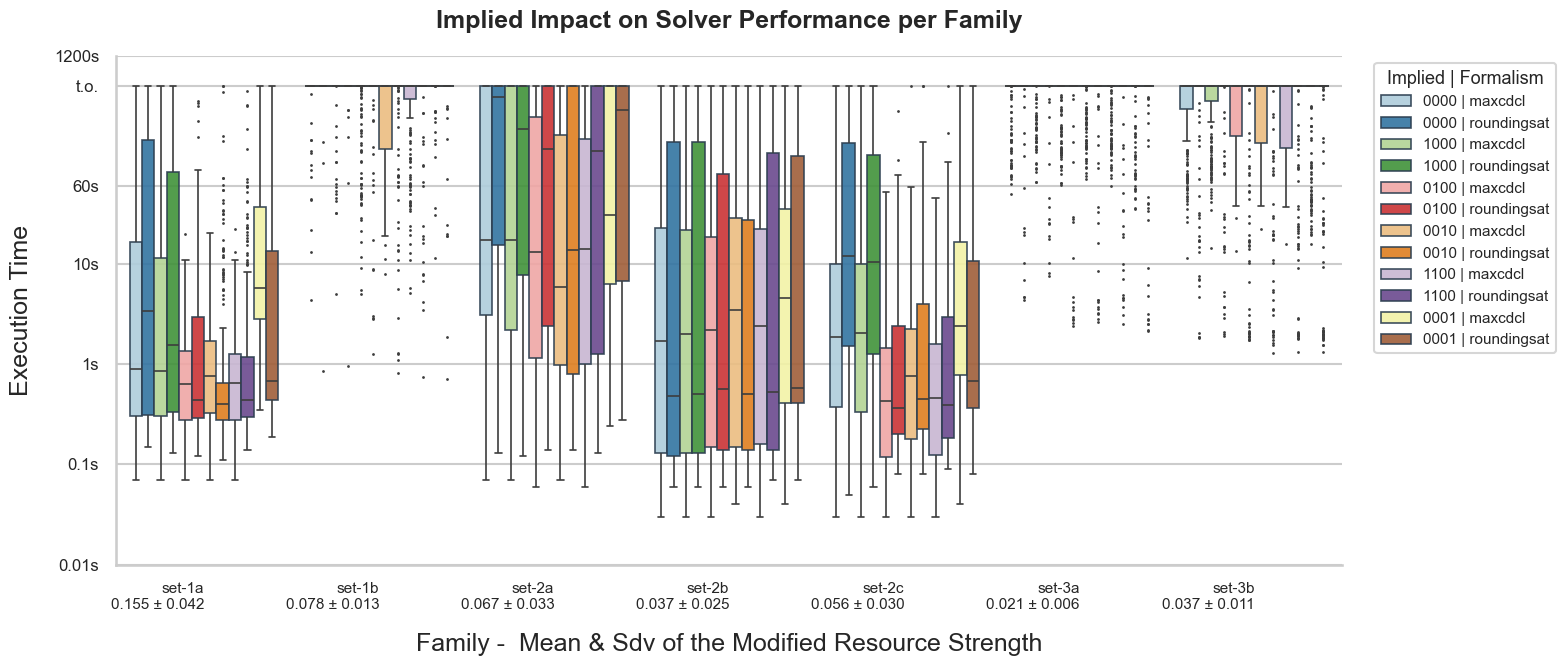

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")


by_family_df = df_wandb.copy()


by_family_df["implied_bitmask_str"] = by_family_df["implied_bitmask"].astype(str)

implied_order = [
    "0000",
    "1000",
    "0100",
    "0010",
    "1100",
    "0001",
]

solver_order = by_family_df["solver"].unique().tolist()

# Combine implied + formalism
by_family_df["group"] = (
    by_family_df["implied_bitmask_str"] + " | " + by_family_df["solver"]
)

group_order = [f"{imp} | {form}" for imp in implied_order for form in solver_order]

# Increased width to 16 to handle the dense grouping per bin
plt.figure(figsize=(16, 7))

# Add padding and label for better aesthetics
ax = sns.boxplot(
    data=by_family_df,
    x="family",
    y="solver.log_real_time",
    hue="group",
    hue_order=group_order,
    linewidth=1.2,
    fliersize=1,
    width=0.85,  # Slightly wider to utilize space
    boxprops={"alpha": 0.9, "edgecolor": "#2c3e50"},
)

timeout_log = np.log10(600)
human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

ymin, ymax = ax.get_ylim()
ymax = max(ymax, timeout_log + 0.2)  # Ensure 600s is visible
ax.set_ylim(ymin, ymax)

ticks, labels = [], []
for t in human_times:
    log_t = np.log10(t)
    ticks.append(log_t)
    labels.append(f"{t}s" if t != 600 else "t.o.")

ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=12)

# Modify xticks labels by adding the mrs range for each family
ticks = ax.get_xticks()
xticklabels = ax.get_xticklabels()
xticklabels = [
    f"{xt.get_text()}\n{mapping_range.loc[mapping_range['family'] == xt.get_text(), 'mrs_mean'].iloc[0]:.3f} ± {mapping_range.loc[mapping_range['family'] == xt.get_text(), 'mrs_std'].iloc[0]:.3f}"
    for xt in xticklabels
]
ax.set_xticks(ticks)
ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=11)

# Labels and Clean X-Axis
ax.set_xlabel("Family -  Mean & Sdv of the Modified Resource Strength", labelpad=15)
ax.set_ylabel("Execution Time", labelpad=15)
ax.set_title("Implied Impact on Solver Performance per Family", pad=20, weight="bold")
plt.xticks(rotation=0, ha="right", fontsize=11)

sns.despine(trim=False)

plt.legend(
    title="Implied | Formalism",
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=11,
)

plt.tight_layout()
plt.show()

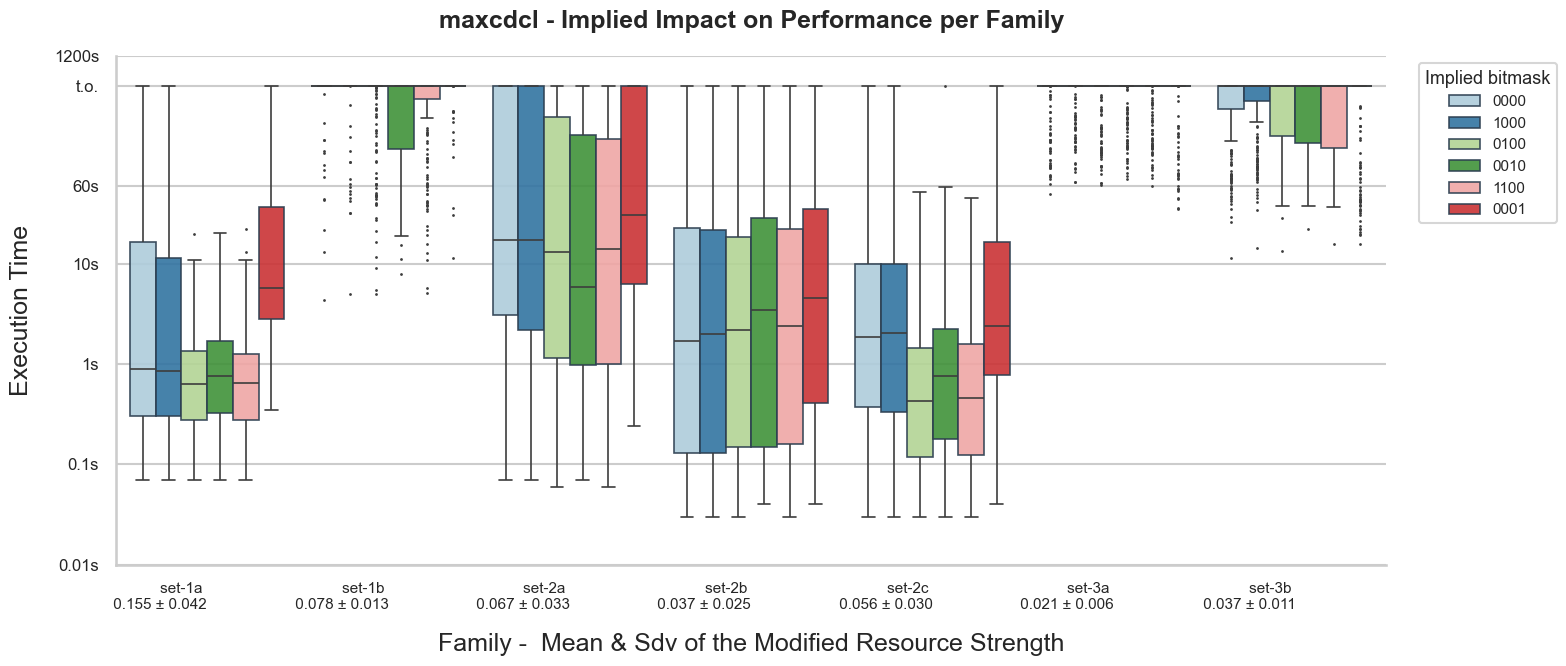

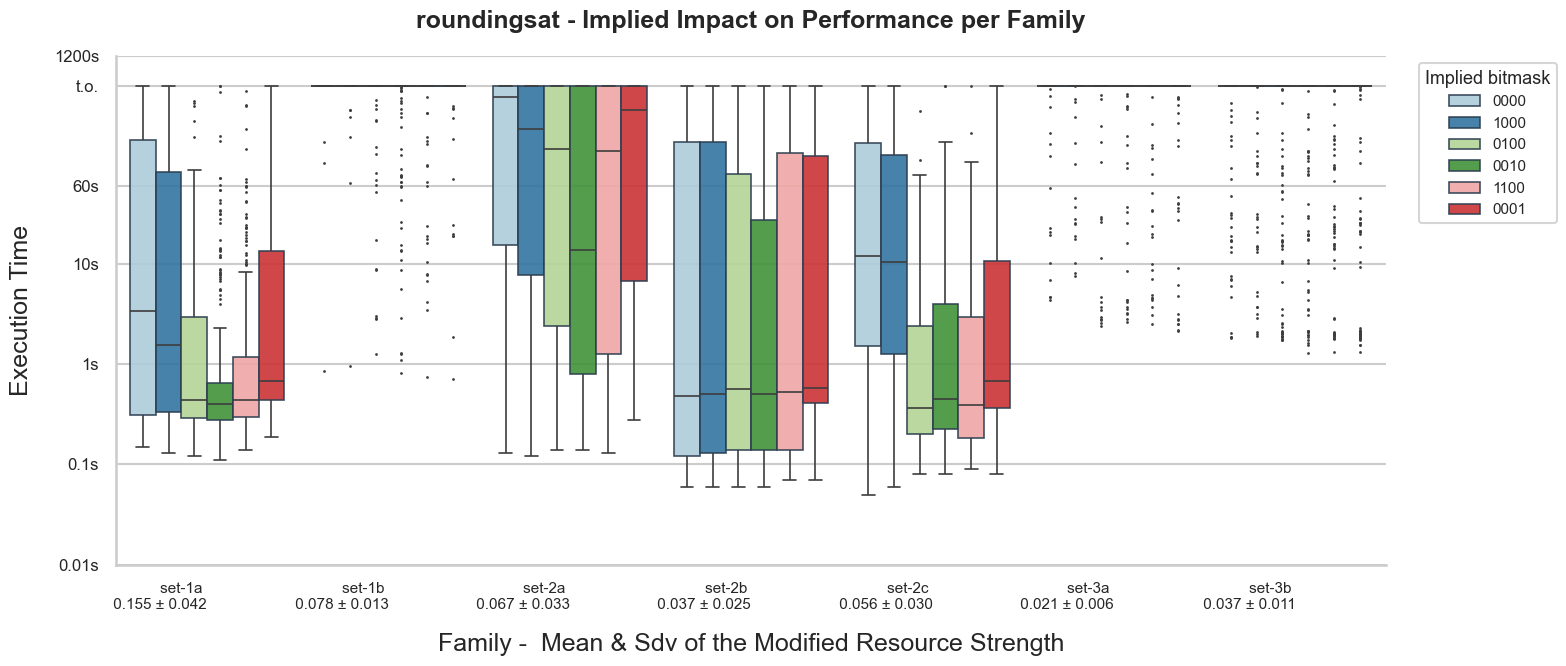

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")


by_family_df = df_wandb.copy()


by_family_df["implied_bitmask_str"] = by_family_df["implied_bitmask"].astype(str)

implied_order = [
    "0000",
    "1000",
    "0100",
    "0010",
    "1100",
    "0001",
]

solver_order = by_family_df["solver"].unique().tolist()

for solver in solver_order:

    # Combine implied + formalism
    by_family_df["group"] = by_family_df["implied_bitmask_str"]

    group_order = [imp for imp in implied_order]

    # Increased width to 16 to handle the dense grouping per bin
    plt.figure(figsize=(16, 7))

    data_df = by_family_df[by_family_df["solver"] == solver]

    # Add padding and label for better aesthetics
    ax = sns.boxplot(
        data=data_df,
        x="family",
        y="solver.log_real_time",
        hue="group",
        hue_order=group_order,
        linewidth=1.2,
        fliersize=1,
        width=0.85,  # Slightly wider to utilize space
        boxprops={"alpha": 0.9, "edgecolor": "#2c3e50"},
    )

    timeout_log = np.log10(600)
    human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

    ymin, ymax = ax.get_ylim()
    ymax = max(ymax, timeout_log + 0.2)  # Ensure 600s is visible
    ax.set_ylim(ymin, ymax)

    ticks, labels = [], []
    for t in human_times:
        log_t = np.log10(t)
        ticks.append(log_t)
        labels.append(f"{t}s" if t != 600 else "t.o.")

    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=12)

    # Modify xticks labels by adding the mrs range for each family
    ticks = ax.get_xticks()
    xticklabels = ax.get_xticklabels()
    xticklabels = [
        f"{xt.get_text()} \n {mapping_range.loc[mapping_range['family'] == xt.get_text(), 'mrs_mean'].iloc[0]:.3f} ± {mapping_range.loc[mapping_range['family'] == xt.get_text(), 'mrs_std'].iloc[0]:.3f}"
        for xt in xticklabels
    ]
    ax.set_xticks(ticks)
    ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=11)

    ax.set_xlabel("Family -  Mean & Sdv of the Modified Resource Strength", labelpad=15)
    ax.set_ylabel("Execution Time", labelpad=15)
    ax.set_title(
        f"{solver} - Implied Impact on Performance per Family",
        pad=20,
        weight="bold",
    )

    plt.xticks(rotation=0, ha="right", fontsize=11)

    sns.despine(trim=False)

    plt.legend(
        title="Implied bitmask",
        title_fontsize=13,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()

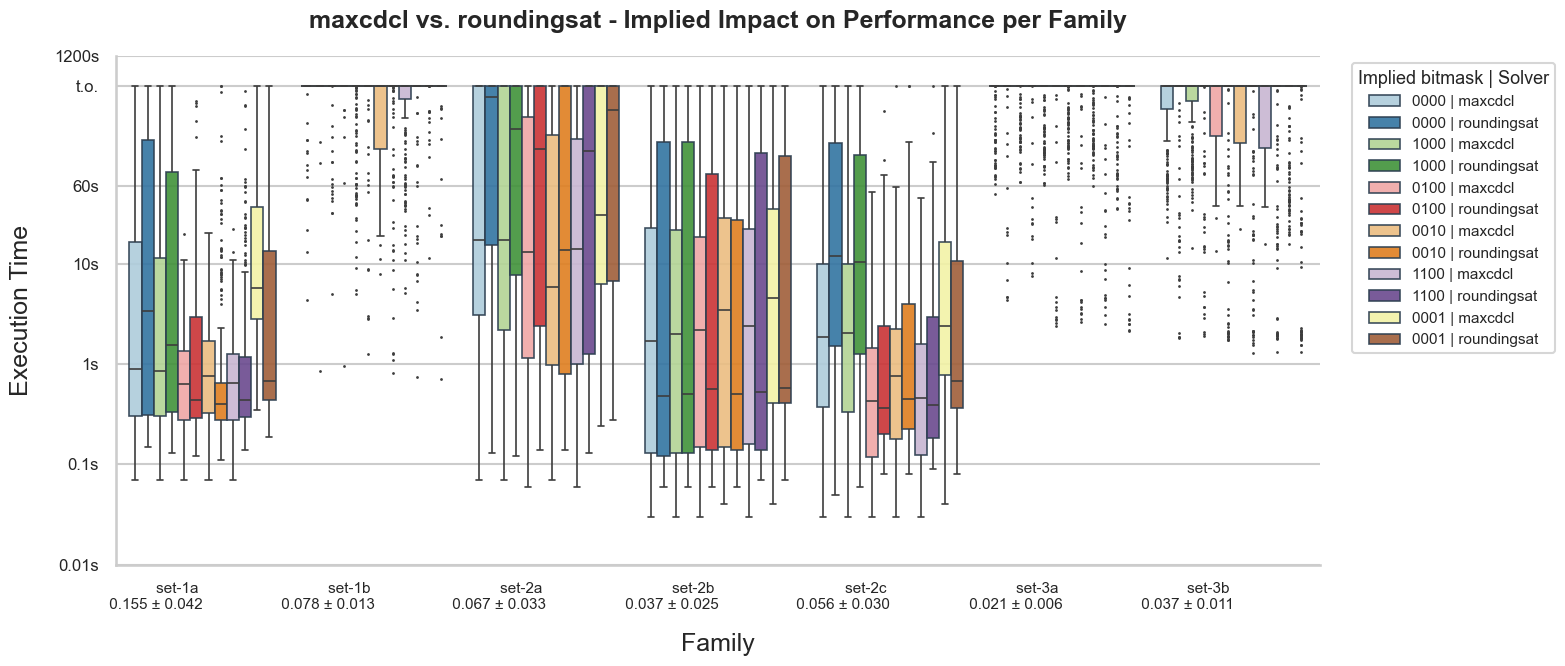

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")


by_family_df = df_wandb.copy()


by_family_df["implied_bitmask_str"] = by_family_df["implied_bitmask"].astype(str)

implied_order = [
    "0000",
    "1000",
    "0100",
    "0010",
    "1100",
    "0001",
]

solver_order = by_family_df["solver"].unique().tolist()

# Combine implied + formalism
by_family_df["group"] = (
    by_family_df["implied_bitmask_str"] + " | " + by_family_df["solver"]
)

group_order = [f"{imp} | {form}" for imp in implied_order for form in solver_order]

# Increased width to 16 to handle the dense grouping per bin
plt.figure(figsize=(16, 7))

# Add padding and label for better aesthetics
ax = sns.boxplot(
    data=by_family_df,
    x="family",
    y="solver.log_real_time",
    hue="group",
    hue_order=group_order,
    linewidth=1.2,
    fliersize=1,
    width=0.85,  # Slightly wider to utilize space
    boxprops={"alpha": 0.9, "edgecolor": "#2c3e50"},
)

timeout_log = np.log10(600)
human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

ymin, ymax = ax.get_ylim()
ymax = max(ymax, timeout_log + 0.2)  # Ensure 600s is visible
ax.set_ylim(ymin, ymax)

ticks, labels = [], []
for t in human_times:
    log_t = np.log10(t)
    ticks.append(log_t)
    labels.append(f"{t}s" if t != 600 else "t.o.")

ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=12)

# Modify xticks labels by adding the mrs range for each family
ticks = ax.get_xticks()
xticklabels = ax.get_xticklabels()
xticklabels = [
    f"{xt.get_text()} \n {mapping_range.loc[mapping_range['family'] == xt.get_text(), 'mrs_mean'].iloc[0]:.3f} ± {mapping_range.loc[mapping_range['family'] == xt.get_text(), 'mrs_std'].iloc[0]:.3f}"
    for xt in xticklabels
]
ax.set_xticks(ticks)
ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=11)


# Labels and Clean X-Axis
ax.set_xlabel("Family", labelpad=15)
ax.set_ylabel("Execution Time", labelpad=15)
ax.set_title(
    f"{' vs. '.join(solver_order)} - Implied Impact on Performance per Family",
    pad=20,
    weight="bold",
)
plt.xticks(rotation=0, ha="right", fontsize=11)

sns.despine(trim=False)

plt.legend(
    title="Implied bitmask | Solver",
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=11,
)

plt.tight_layout()
plt.show()